In [29]:
import numpy as np
import os
from matplotlib import pyplot as plt
from matplotlib.ticker import LogLocator, MaxNLocator, NullLocator, FixedLocator, FixedFormatter
import csv

from common import make_canvas

LTH figures

In [32]:
d = 10000
dstop = 1000
k = 5
train_size = 100_000
test_size = train_size
train_noise = 0.2
tol = 1e-12
epochs = 300
batch_size = 512

algo_name = "SGD"
lr = 1e-3

plot_every = 50 if algo_name == "SGD" else 5

filename = f'LTH/harm_{algo_name}_d{d}_dstop{dstop}_k{k}_noise{train_noise}_bs{batch_size}_lr{lr}'
with open(filename+'.csv', 'rt') as csvfile:
    data = np.genfromtxt(csvfile, delimiter=',', names=True)

epoch_range = data["epoch"].astype(np.int64)[::plot_every]
train_loss_orig = data["train_loss_orig"].astype(np.float64)[::plot_every]
test_loss_orig = data["test_loss_orig"].astype(np.float64)[::plot_every]
train_loss_cp = data["train_loss_cp"].astype(np.float64)[::plot_every]
test_loss_cp = data["test_loss_cp"].astype(np.float64)[::plot_every]
train_loss_naive = data["train_loss_naive"].astype(np.float64)[::plot_every]
test_loss_naive = data["test_loss_naive"].astype(np.float64)[::plot_every]

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


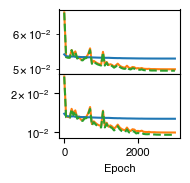

In [28]:
fig, axs = make_canvas(rows=2, cols=1, axes_width_pt=80, axes_aspect=1, sharex=True, gridspec_kw={'hspace': 0})

axs[0].plot(epoch_range, train_loss_cp, color='tab:orange',marker=None, markersize=2, label=f'Compressed d\'={dstop}')
axs[0].plot(epoch_range, train_loss_naive, color='tab:blue',  marker=None, markersize=2, label=f'Naive d\'={dstop}')
axs[0].plot(epoch_range, train_loss_orig,  color='tab:green', marker=None, markersize=2, ls='--', label=f'Original d={d}')
axs[0].set_yscale('log')
# axs[0].yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
# axs[0].yaxis.set_minor_locator(NullLocator()) 
# axs[0].set_ylabel('Train loss')
# axs[0].legend()

axs[1].plot(epoch_range, test_loss_cp, color='tab:orange', marker=None, markersize=2, label=f'Compressed d\'={dstop}')
axs[1].plot(epoch_range, test_loss_naive, color='tab:blue', marker=None, markersize=2, label=f'Naive d\'={dstop}')
axs[1].plot(epoch_range, test_loss_orig,  color='tab:green', marker=None, markersize=2, ls='--', label=f'Original d={d}')
axs[1].set_xlabel('Epoch')
axs[1].set_yscale('log')

# enforce ticks at only 0.01 and 0.02
yticks = [0.01, 0.02]
axs[1].yaxis.set_major_locator(FixedLocator(yticks))
# axs[1].yaxis.set_major_formatter(FixedFormatter([f"{t:.2f}" for t in yticks]))
axs[1].yaxis.set_minor_locator(FixedLocator([]))  # remove minor ticks

plt.tight_layout()
plt.savefig('out.pdf', format='pdf', bbox_inches='tight', pad_inches=0)
plt.show()

Compress trainds figures

In [54]:
d = 10_000  # train size
dstop = 1_000 # compressed training dataset size
k = 5
train_noise = 3.0
test_size = 100_000
hidden_dim = 50
epochs = 400
batch_size = 256

algo_name = 'SGD'
lr = 1e-2

plot_every = 10

filename = f'CPTDS/teacher_{algo_name}_d{d}_dstop{dstop}_k{k}_noise{train_noise}_hidden{hidden_dim}_bs{batch_size}_lr{lr}'
with open(filename+'.csv', 'rt') as csvfile:
    data = np.genfromtxt(csvfile, delimiter=',', names=True)

epoch_range = data["epoch"].astype(np.int64)[::plot_every]
train_loss_orig = data["train_loss_orig"].astype(np.float64)[::plot_every]
test_loss_orig = data["test_loss_orig"].astype(np.float64)[::plot_every]
train_loss_cp = data["train_loss_cp"].astype(np.float64)[::plot_every]
test_loss_cp = data["test_loss_cp"].astype(np.float64)[::plot_every]
train_loss_naive = data["train_loss_naive"].astype(np.float64)[::plot_every]
test_loss_naive = data["test_loss_naive"].astype(np.float64)[::plot_every]

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


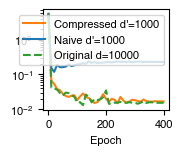

In [ ]:
fig, axs = make_canvas(rows=1, cols=1, axes_width_pt=80, axes_aspect=0.75, sharex=True, gridspec_kw={'hspace': 0})

axs.plot(epoch_range, test_loss_cp, color='tab:orange', marker=None, markersize=2, label=f'Compressed d\'={dstop}')
axs.plot(epoch_range, test_loss_naive, color='tab:blue', marker=None, markersize=2, label=f'Naive d\'={dstop}')
axs.plot(epoch_range, test_loss_orig,  color='tab:green', marker=None, markersize=2, ls='--', label=f'Original d={d}')
axs.set_xlabel('Epoch')
axs.set_yscale('log')
# axs.legend()

# # enforce ticks at only 0.01 and 0.02
# yticks = [0.01, 0.02]
# axs[1].yaxis.set_major_locator(FixedLocator(yticks))
# # axs[1].yaxis.set_major_formatter(FixedFormatter([f"{t:.2f}" for t in yticks]))
# axs[1].yaxis.set_minor_locator(FixedLocator([]))  # remove minor ticks

plt.tight_layout()
plt.savefig('out.pdf', format='pdf', bbox_inches='tight', pad_inches=0)
plt.show()

Cylindrical harmonic

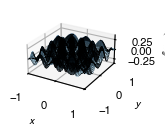

In [22]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from scipy.special import jv  # Bessel J_ν

# -------- publication style --------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

AX_WIDTH_PT = 100.0
ASPECT = 2/3
fig_w_in = AX_WIDTH_PT / 72.0
fig_h_in = ASPECT * fig_w_in

fig = plt.figure(figsize=(fig_w_in, fig_h_in))
ax = fig.add_axes([0, 0, 1, 1], projection="3d")

# ticks & frame style
ax.tick_params(axis="both", which="both", labelsize=8, width=0.75, length=2.5)
ax.tick_params(axis="z", which="both", labelsize=8, width=0.75, length=2.5)
for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    try:
        axis.line.set_linewidth(0.75)
    except Exception:
        pass

# -------- function & grid --------
def f(x, y):
    r = np.hypot(x, y)
    theta = np.arctan2(y, x)
    return jv(6, 20.0 * r) * np.cos(6.0 * theta)

n = 200
x = np.linspace(-1.0, 1.0, n)
y = np.linspace(-1.0, 1.0, n)
X, Y = np.meshgrid(x, y, indexing="xy")
Z = f(X, Y)

# -------- plot (no surface mesh) --------
surf = ax.plot_surface(
    X, Y, Z, rstride=2, cstride=2, cmap="Blues",
    linewidth=0, edgecolor="none", antialiased=True, alpha=0.9
)

ax.contour(X, Y, Z, levels=40, colors="k", linewidths=0.4)

ax.set_xlim(-1, 1); ax.set_ylim(-1, 1)
ax.set_xlabel(r"$x$", fontsize=8, labelpad=2)
ax.set_ylabel(r"$y$", fontsize=8, labelpad=2)
ax.set_zlabel(r"$f(x,y)$", fontsize=8, labelpad=2)
ax.view_init(elev=25, azim=-60)

try:
    ax.set_box_aspect((1, 1, 0.5))
except Exception:
    pass

# -------- export --------
out_path = "cyl_harmonic.pdf"
fig.savefig(out_path, bbox_inches="tight", pad_inches=0.0)
plt.show()